# 02. Pricing and Promotions

Pricing is one of the highest-leverage causal inference problems in industry.

A small change in price can affect demand, revenue, margin, inventory, customer acquisition, retention, and brand perception. Promotions add another layer: a discount can increase purchases today while reducing full-price demand tomorrow.

This notebook treats pricing and promotions as causal decision problems. We will use simulations to study:

- why naive price elasticity estimates can be badly biased,
- how randomized price variation and instruments help identify demand response,
- why revenue lift is not the same as profit lift,
- how discount depth changes customer behavior,
- how promotions can create stockpiling and post-promotion dips,
- how to translate estimates into a pricing recommendation.

## Learning Goals

By the end of this notebook, you should be able to:

- Define causal price elasticity and distinguish it from predictive demand modeling.
- Explain why observed prices are often endogenous.
- Estimate elasticity from observational panel data and diagnose bias.
- Use instrumental-variable logic for pricing when valid cost shocks are available.
- Analyze a randomized discount-depth experiment.
- Evaluate promotions using contribution profit, not only revenue.
- Detect pull-forward and stockpiling using distributed-lag effects.
- Build a professional pricing readout with assumptions, estimates, risks, and decision guidance.

## 1. Setup

We will use pandas, statsmodels, linearmodels, scipy, seaborn, and Graphviz.

In [1]:
import warnings

warnings.filterwarnings("ignore")

from IPython.display import Markdown, display
from graphviz import Digraph
from linearmodels.iv import IV2SLS
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import expit
from scipy.stats import norm
import seaborn as sns
import statsmodels.formula.api as smf


rng = np.random.default_rng(20260430)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 130


def dollars(x, digits=0):
    return f"${x:,.{digits}f}"


def pct(x, digits=1):
    return f"{100 * x:.{digits}f}%"


def ratio(x, digits=2):
    return f"{x:.{digits}f}"


def styled_table(df, money_cols=None, pct_cols=None, ratio_cols=None):
    money_cols = money_cols or []
    pct_cols = pct_cols or []
    ratio_cols = ratio_cols or []

    fmt = {}
    for col in money_cols:
        fmt[col] = lambda v: dollars(v, 2) if abs(v) < 100 else dollars(v, 0)
    for col in pct_cols:
        fmt[col] = lambda v: pct(v, 1)
    for col in ratio_cols:
        fmt[col] = lambda v: f"{v:,.3f}"

    return df.style.format(fmt)

## 2. The Causal Question in Pricing

A predictive demand model asks:

> Given the observed price and context, how many units will we sell?

A causal pricing model asks:

> What would demand have been if we had set a different price?

That counterfactual distinction matters. In potential-outcome notation:

$$
Y_i(p) = \text{outcome for unit } i \text{ if price were set to } p
$$

For a price change from $p_0$ to $p_1$, the causal effect is:

$$
E[Y(p_1)-Y(p_0)]
$$

For continuous prices, a common estimand is own-price elasticity:

$$
\epsilon = \frac{\partial Q/Q}{\partial P/P}
= \frac{\partial \log Q}{\partial \log P}
$$

If $\epsilon=-2$, then a 1% price increase decreases quantity demanded by approximately 2%, holding other demand drivers fixed.

For business decisions, elasticity is only an intermediate object. The decision objective is usually profit:

$$
\Pi(p) = (p-c)Q(p)
$$

where $c$ is marginal cost. A price can increase revenue while decreasing profit, or decrease units while increasing profit. The causal estimate must be connected to the decision metric.

## 3. Why Pricing Is Hard: Prices Are Usually Endogenous

Observed prices are often chosen by the business in response to expected demand.

Examples:

- A retailer raises prices when demand is strong.
- A marketplace surges prices when supply is tight.
- A brand discounts when inventory is high.
- A competitor's promotion triggers a defensive price cut.
- A store manager marks down slow-moving products.

If we regress sales on observed prices, the coefficient can mix two forces:

1. the causal effect of price on demand,
2. the business rule that sets prices higher or lower when demand conditions change.

This is the classic price endogeneity problem. Demand estimation papers often focus on this issue because price can be correlated with unobserved demand shocks. In an industry project, this is the first thing to look for before believing an elasticity estimate.

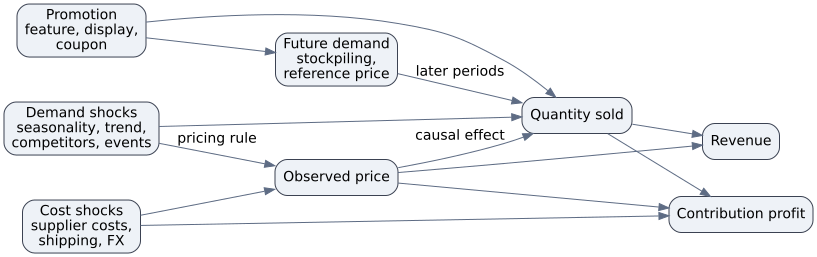

In [2]:
dot = Digraph("pricing_dag", format="svg")
dot.attr(rankdir="LR", bgcolor="transparent")
dot.attr("node", shape="box", style="rounded,filled", color="#3B4252", fillcolor="#EEF2F7", fontname="DejaVu Sans")
dot.attr("edge", color="#5E6C84", fontname="DejaVu Sans")

dot.node("cost", "Cost shocks\nsupplier costs,\nshipping, FX")
dot.node("demand", "Demand shocks\nseasonality, trend,\ncompetitors, events")
dot.node("price", "Observed price")
dot.node("quantity", "Quantity sold")
dot.node("revenue", "Revenue")
dot.node("profit", "Contribution profit")
dot.node("promo", "Promotion\nfeature, display,\ncoupon")
dot.node("future", "Future demand\nstockpiling,\nreference price")

dot.edge("cost", "price")
dot.edge("demand", "price", label="pricing rule")
dot.edge("demand", "quantity")
dot.edge("price", "quantity", label="causal effect")
dot.edge("quantity", "revenue")
dot.edge("price", "revenue")
dot.edge("quantity", "profit")
dot.edge("price", "profit")
dot.edge("cost", "profit")
dot.edge("promo", "quantity")
dot.edge("promo", "future")
dot.edge("future", "quantity", label="later periods")

dot

Hendel and Nevo (2006) study sales and consumer inventory and emphasize that temporary price reductions can create large sales increases partly because consumers stockpile for future consumption. Mela, Gupta, and Lehmann (1997) and Pauwels, Hanssens, and Siddarth (2002) study longer-run promotion and advertising effects on brand choice and category behavior. These papers are useful reminders that pricing and promotions can have dynamic consequences, not just same-day effects.

The rest of this notebook turns these ideas into a practical workflow.

## 4. Running Example: Everyday Price Elasticity

Imagine an e-commerce retailer selling multiple products across stores or regions. The pricing team has historical product-store-week data:

- price,
- unit cost,
- units sold,
- revenue,
- contribution margin,
- product, store, and week identifiers.

The team wants to estimate price elasticity and decide whether current prices should move up or down.

We will simulate the data with a known true elasticity. The crucial feature is that price is not randomly assigned. The pricing system raises prices when expected demand is high.

In [3]:
def simulate_pricing_panel(n_products=14, n_stores=16, n_weeks=52, seed=101):
    local_rng = np.random.default_rng(seed)

    products = [f"SKU_{i:02d}" for i in range(n_products)]
    stores = [f"Store_{j:02d}" for j in range(n_stores)]

    base_price = pd.Series(local_rng.uniform(18, 95, n_products), index=products)
    base_cost_ratio = pd.Series(local_rng.uniform(0.42, 0.66, n_products), index=products)
    product_demand = pd.Series(local_rng.normal(0.0, 0.55, n_products), index=products)
    store_demand = pd.Series(local_rng.normal(0.0, 0.32, n_stores), index=stores)
    store_markup = pd.Series(local_rng.normal(0.0, 0.035, n_stores), index=stores)

    true_elasticity = -1.75
    rows = []

    for product in products:
        for store in stores:
            persistent_demand = local_rng.normal(0, 0.15)
            for week in range(n_weeks):
                seasonal = 0.22 * np.sin(2 * np.pi * week / 26) + 0.08 * np.cos(2 * np.pi * week / 13)
                demand_shock = 0.65 * persistent_demand + local_rng.normal(0, 0.35)
                cost_shock = local_rng.normal(0, 0.08)

                unit_cost = base_price[product] * base_cost_ratio[product] * np.exp(cost_shock)

                # The pricing rule is endogenous: prices rise when expected demand is high.
                log_price = (
                    np.log(base_price[product])
                    + 0.55 * cost_shock
                    + 0.24 * demand_shock
                    + store_markup[store]
                    + local_rng.normal(0, 0.035)
                )
                price = np.exp(log_price)

                log_units = (
                    6.2
                    + product_demand[product]
                    + store_demand[store]
                    + seasonal
                    + 0.85 * demand_shock
                    + true_elasticity * (np.log(price) - np.log(base_price[product]))
                    + local_rng.normal(0, 0.18)
                )
                units = np.maximum(np.exp(log_units), 1)
                revenue = price * units
                contribution_profit = (price - unit_cost) * units

                rows.append(
                    {
                        "product": product,
                        "store": store,
                        "week": week,
                        "product_store": f"{product}_{store}",
                        "price": price,
                        "unit_cost": unit_cost,
                        "units": units,
                        "revenue": revenue,
                        "contribution_profit": contribution_profit,
                        "demand_shock_unobserved": demand_shock,
                        "true_elasticity": true_elasticity,
                    }
                )

    df = pd.DataFrame(rows)
    df["log_price"] = np.log(df["price"])
    df["log_cost"] = np.log(df["unit_cost"])
    df["log_units"] = np.log(df["units"])
    return df


pricing = simulate_pricing_panel()

display(pricing.head())
print(f"Rows: {len(pricing):,}")
print(f"Products: {pricing['product'].nunique()}")
print(f"Stores: {pricing['store'].nunique()}")
print(f"Weeks: {pricing['week'].nunique()}")
print(f"True elasticity: {pricing['true_elasticity'].iloc[0]:.2f}")

,product,store,week,product_store,price,unit_cost,units,revenue,contribution_profit,demand_shock_unobserved,true_elasticity,log_price,log_cost,log_units
0,SKU_00,Store_00,0,SKU_00_Store_00,73.571826,48.423691,2757.993889,202910.646804,69358.403391,-0.167774,-1.75,4.298262,3.879989,7.922259
1,SKU_00,Store_00,1,SKU_00_Store_00,85.994920,61.370613,1619.714798,139287.244724,39884.354111,-0.421172,-1.75,4.454288,4.116931,7.390005
2,SKU_00,Store_00,2,SKU_00_Store_00,90.308709,57.209390,2190.240268,197797.771107,72495.462250,0.427364,-1.75,4.503234,4.046718,7.691767
3,SKU_00,Store_00,3,SKU_00_Store_00,107.225114,67.507646,1769.406999,189724.867859,70276.366358,0.301128,-1.75,4.674930,4.212241,7.478400
4,SKU_00,Store_00,4,SKU_00_Store_00,77.702545,60.110874,1390.946855,108080.109963,24469.078669,-0.526568,-1.75,4.352888,4.096191,7.237740


Rows: 11,648
Products: 14
Stores: 16
Weeks: 52
True elasticity: -1.75


The unobserved demand shock is included because this is a simulation. In real data, that column is exactly what we do not observe. The price endogeneity problem comes from this hidden demand shock influencing both price and units.

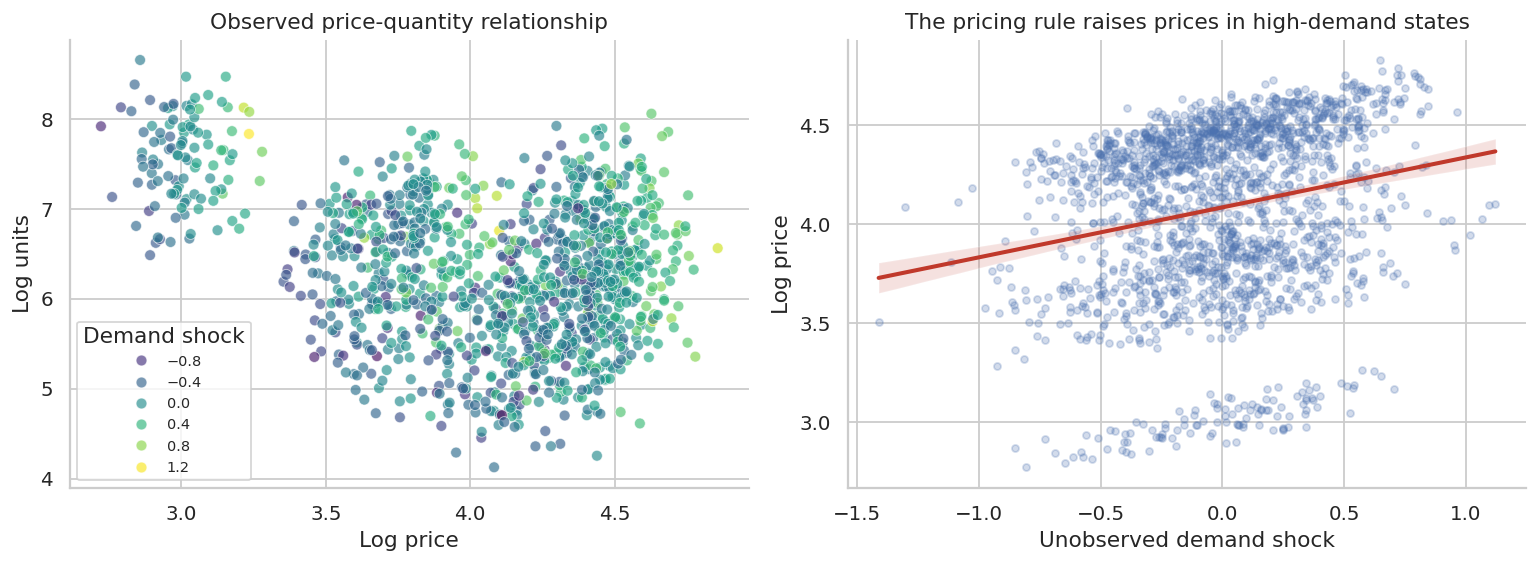

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(
    data=pricing.sample(1200, random_state=4),
    x="log_price",
    y="log_units",
    hue="demand_shock_unobserved",
    palette="viridis",
    alpha=0.65,
    ax=axes[0],
)
axes[0].set_title("Observed price-quantity relationship")
axes[0].set_xlabel("Log price")
axes[0].set_ylabel("Log units")
axes[0].legend(title="Demand shock", loc="best", fontsize=8)

sns.regplot(
    data=pricing.sample(1800, random_state=8),
    x="demand_shock_unobserved",
    y="log_price",
    scatter_kws={"alpha": 0.25, "s": 15},
    line_kws={"color": "#C0392B"},
    ax=axes[1],
)
axes[1].set_title("The pricing rule raises prices in high-demand states")
axes[1].set_xlabel("Unobserved demand shock")
axes[1].set_ylabel("Log price")

plt.tight_layout()
plt.show()

The second plot is the danger. Price is correlated with an unobserved demand driver. If we omit that demand driver, the estimated price coefficient can be much less negative than the true causal elasticity.

## 5. Naive and Fixed-Effect Elasticity Estimates

Start with two observational regressions:

1. naive log-log demand,
2. log-log demand with product, store, and week fixed effects.

The log-log coefficient on price is interpreted as elasticity:

$$
\log(Q_{gst}) = \alpha + \beta \log(P_{gst}) + \varepsilon_{gst}
$$

With fixed effects:

$$
\log(Q_{gst}) = \alpha_g + \alpha_s + \lambda_t + \beta \log(P_{gst}) + \varepsilon_{gst}
$$

Fixed effects remove stable product/store differences and common week shocks. They do not automatically remove product-store-week demand shocks that the pricing system observed and acted on.

In [5]:
naive_model = smf.ols("log_units ~ log_price", data=pricing).fit(
    cov_type="cluster", cov_kwds={"groups": pricing["product_store"]}
)

fe_model = smf.ols(
    "log_units ~ log_price + C(product) + C(store) + C(week)",
    data=pricing,
).fit(cov_type="cluster", cov_kwds={"groups": pricing["product_store"]})

elasticity_comparison = pd.DataFrame(
    [
        {
            "model": "True causal elasticity",
            "estimate": pricing["true_elasticity"].iloc[0],
            "std_error": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        },
        {
            "model": "Naive OLS",
            "estimate": naive_model.params["log_price"],
            "std_error": naive_model.bse["log_price"],
            "ci_low": naive_model.conf_int().loc["log_price", 0],
            "ci_high": naive_model.conf_int().loc["log_price", 1],
        },
        {
            "model": "Product/store/week FE",
            "estimate": fe_model.params["log_price"],
            "std_error": fe_model.bse["log_price"],
            "ci_low": fe_model.conf_int().loc["log_price", 0],
            "ci_high": fe_model.conf_int().loc["log_price", 1],
        },
    ]
)

display(styled_table(elasticity_comparison, ratio_cols=["estimate", "std_error", "ci_low", "ci_high"]))

,model,estimate,std_error,ci_low,ci_high
0,True causal elasticity,-1.750,nan,nan,nan
1,Naive OLS,-0.471,0.115,-0.695,-0.246
2,Product/store/week FE,0.718,0.023,0.672,0.763


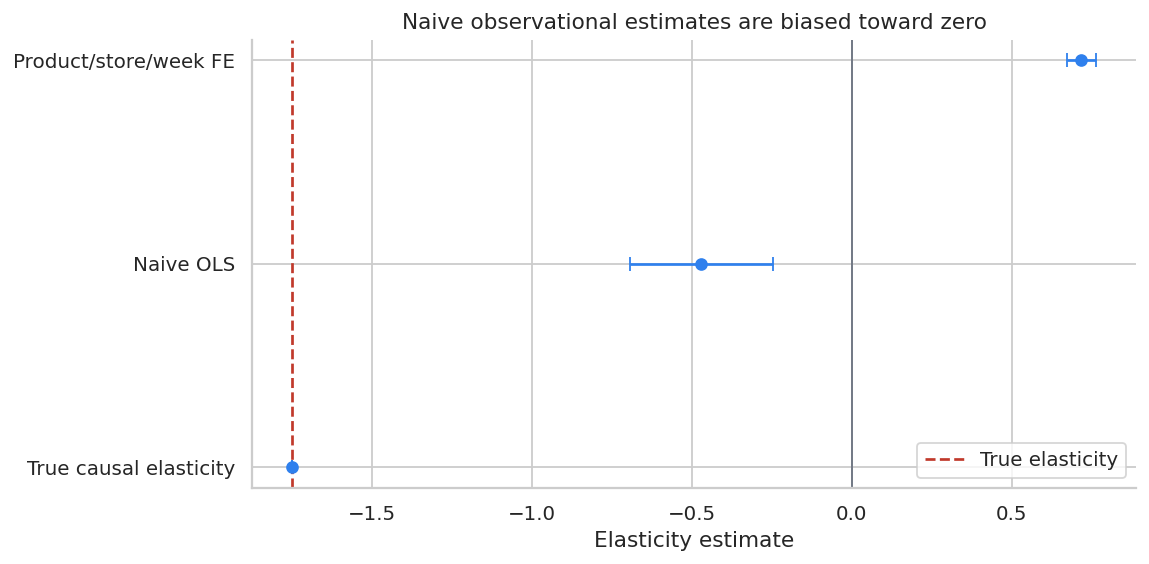

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))

plot_elast = elasticity_comparison.dropna(subset=["estimate"]).copy()
plot_elast["y"] = np.arange(len(plot_elast))

ax.errorbar(
    plot_elast["estimate"],
    plot_elast["y"],
    xerr=[
        plot_elast["estimate"] - plot_elast["ci_low"].fillna(plot_elast["estimate"]),
        plot_elast["ci_high"].fillna(plot_elast["estimate"]) - plot_elast["estimate"],
    ],
    fmt="o",
    color="#2F80ED",
    capsize=4,
)
ax.axvline(pricing["true_elasticity"].iloc[0], color="#C0392B", linestyle="--", label="True elasticity")
ax.axvline(0, color="#6B7280", linewidth=1)
ax.set_yticks(plot_elast["y"])
ax.set_yticklabels(plot_elast["model"])
ax.set_title("Naive observational estimates are biased toward zero")
ax.set_xlabel("Elasticity estimate")
ax.legend()
plt.tight_layout()
plt.show()

The fixed-effect model improves the comparison but still does not fully solve the problem. If the pricing system observes a demand forecast that the analyst does not observe, price remains correlated with the regression error.

This is why pricing teams try to create or find exogenous price variation.

## 6. Instrumental-Variable Logic for Pricing

One way to estimate causal elasticity is to use a variable that shifts price but does not directly shift demand. Cost shocks are a common candidate:

- supplier cost changes,
- shipping cost changes,
- exchange-rate shocks,
- input commodity prices,
- platform fee changes.

The logic is:

$$
Z \rightarrow P \rightarrow Q
$$

where $Z$ shifts price, but affects quantity only through price after controls.

The exclusion restriction is strong. A cost shock is not valid if it changes product availability, shipping speed, quality, assortment, advertising, or customer expectations. Still, the example is useful because it shows the structure of the argument.

In [7]:
first_stage = smf.ols(
    "log_price ~ log_cost + C(product) + C(store) + C(week)",
    data=pricing,
).fit(cov_type="cluster", cov_kwds={"groups": pricing["product_store"]})

iv_model = IV2SLS.from_formula(
    "log_units ~ 1 + C(product) + C(store) + C(week) + [log_price ~ log_cost]",
    data=pricing,
).fit(cov_type="clustered", clusters=pricing["product_store"])

iv_summary = pd.DataFrame(
    [
        {
            "model": "True causal elasticity",
            "estimate": pricing["true_elasticity"].iloc[0],
            "std_error": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        },
        {
            "model": "FE OLS",
            "estimate": fe_model.params["log_price"],
            "std_error": fe_model.bse["log_price"],
            "ci_low": fe_model.conf_int().loc["log_price", 0],
            "ci_high": fe_model.conf_int().loc["log_price", 1],
        },
        {
            "model": "IV with cost instrument",
            "estimate": iv_model.params["log_price"],
            "std_error": iv_model.std_errors["log_price"],
            "ci_low": iv_model.conf_int().loc["log_price", "lower"],
            "ci_high": iv_model.conf_int().loc["log_price", "upper"],
        },
    ]
)

display(styled_table(iv_summary, ratio_cols=["estimate", "std_error", "ci_low", "ci_high"]))
print(f"First-stage coefficient on log cost: {first_stage.params['log_cost']:.3f}")
print(f"First-stage t-statistic: {first_stage.tvalues['log_cost']:.1f}")

,model,estimate,std_error,ci_low,ci_high
0,True causal elasticity,-1.750,nan,nan,nan
1,FE OLS,0.718,0.023,0.672,0.763
2,IV with cost instrument,-1.720,0.074,-1.865,-1.576


First-stage coefficient on log cost: 0.558
First-stage t-statistic: 50.8


The IV estimate is much closer to the true elasticity in this simulation because the instrument creates price variation independent of the unobserved demand shock.

In real pricing work, the most important part of an IV analysis is not the software command. It is the credibility of the instrument:

- Is the instrument strongly related to price?
- Could it affect demand through any other path?
- Does it change product availability or customer experience?
- Is the estimate local to a subset of prices, products, or stores?

## 7. From Elasticity to Price Decisions

Suppose we have an elasticity estimate and want to decide whether to adjust price for a product. A constant-elasticity demand approximation is:

$$
Q(p) = A p^\epsilon
$$

The profit curve is:

$$
\Pi(p) = (p-c)A p^\epsilon
$$

We can calibrate $A$ using current price and current quantity, then compare the price implied by different elasticity estimates.

In [8]:
def price_response_curve(current_price, current_units, unit_cost, elasticity, price_grid):
    A = current_units / (current_price ** elasticity)
    units = A * (price_grid ** elasticity)
    revenue = price_grid * units
    profit = (price_grid - unit_cost) * units
    return pd.DataFrame(
        {
            "price": price_grid,
            "units": units,
            "revenue": revenue,
            "profit": profit,
            "elasticity": elasticity,
        }
    )


target = pricing.query("product == 'SKU_03'").copy()
current_price = target["price"].mean()
current_units = target["units"].mean()
unit_cost = target["unit_cost"].mean()
price_grid = np.linspace(current_price * 0.65, current_price * 1.45, 120)

curves = []
for label, elasticity in [
    ("Naive OLS elasticity", naive_model.params["log_price"]),
    ("FE OLS elasticity", fe_model.params["log_price"]),
    ("IV elasticity", iv_model.params["log_price"]),
    ("True elasticity", pricing["true_elasticity"].iloc[0]),
]:
    curve = price_response_curve(current_price, current_units, unit_cost, elasticity, price_grid)
    curve["model"] = label
    curves.append(curve)

price_curves = pd.concat(curves, ignore_index=True)
best_prices = (
    price_curves.loc[price_curves.groupby("model")["profit"].idxmax(), ["model", "price", "units", "revenue", "profit"]]
    .sort_values("model")
    .reset_index(drop=True)
)

display(
    styled_table(
        best_prices,
        money_cols=["price", "revenue", "profit"],
        ratio_cols=["units"],
    )
)

,model,price,units,revenue,profit
0,FE OLS elasticity,$93.44,345.857,"$32,316","$21,178"
1,IV elasticity,$76.97,195.094,"$15,017","$8,735"
2,Naive OLS elasticity,$93.44,222.398,"$20,780","$13,618"
3,True elasticity,$75.24,201.962,"$15,196","$8,692"


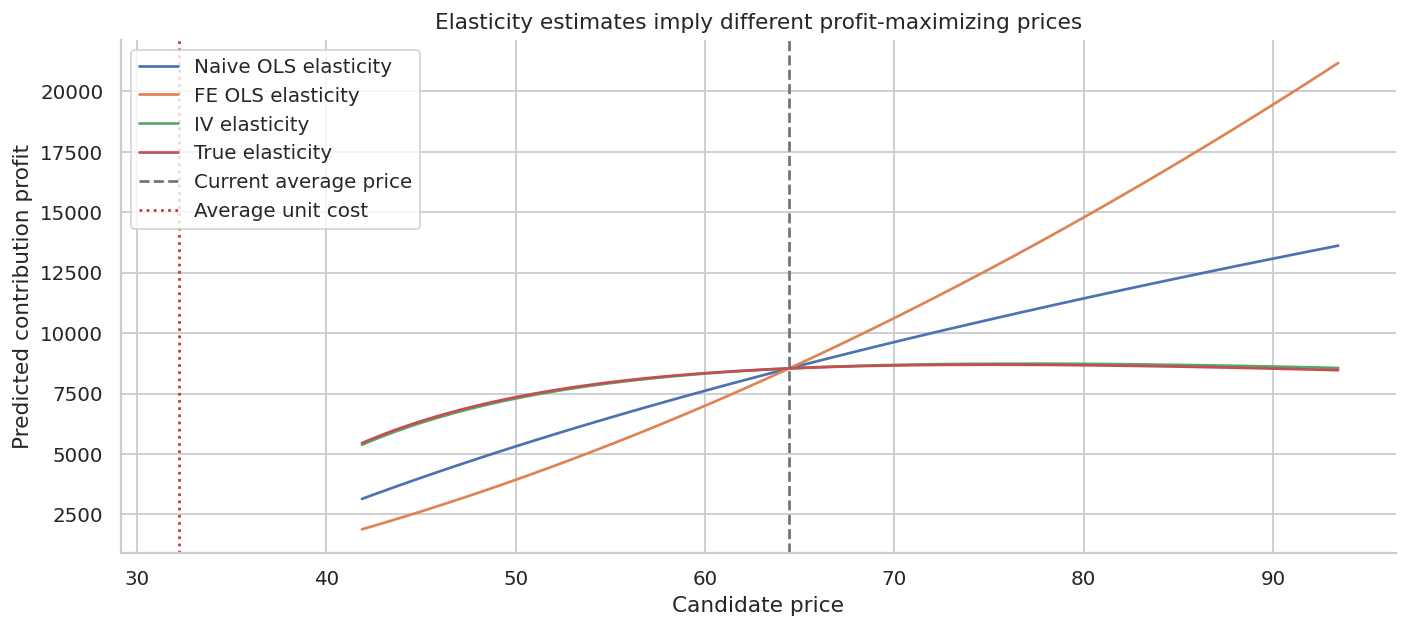

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=price_curves, x="price", y="profit", hue="model", ax=ax)
ax.axvline(current_price, color="#6B7280", linestyle="--", label="Current average price")
ax.axvline(unit_cost, color="#C0392B", linestyle=":", label="Average unit cost")
ax.set_title("Elasticity estimates imply different profit-maximizing prices")
ax.set_xlabel("Candidate price")
ax.set_ylabel("Predicted contribution profit")
ax.legend()
plt.tight_layout()
plt.show()

The naive estimate tends to make demand look too insensitive to price. That can lead to overly aggressive price increases. A biased elasticity estimate is not just a statistical issue; it changes the recommended price.

## 8. Randomized Discount-Depth Experiment

Now switch from everyday price elasticity to promotions.

Suppose a subscription business wants to offer a first-order discount. The team can randomize eligible customers to:

- no discount,
- 10% discount,
- 20% discount,
- 30% discount.

The outcome should not be only conversion or revenue. A deeper discount can increase orders while reducing margin per order.

The treatment is multi-valued:

$$
D_i \in \{0, 0.10, 0.20, 0.30\}
$$

The causal object is a dose-response curve:

$$
E[Y_i(d)]
$$

for each discount depth $d$.

In [10]:
def simulate_discount_experiment(n=80_000, seed=222):
    local_rng = np.random.default_rng(seed)

    discount_depth = local_rng.choice([0.00, 0.10, 0.20, 0.30], size=n, p=[0.25, 0.25, 0.25, 0.25])
    list_price = local_rng.lognormal(mean=np.log(74), sigma=0.20, size=n)
    unit_cost = list_price * local_rng.uniform(0.38, 0.52, size=n)
    prior_visits = local_rng.poisson(2.6, size=n)
    loyalty = local_rng.beta(2.8, 2.0, size=n)
    price_sensitivity = local_rng.beta(2.0, 2.6, size=n)
    urgency = local_rng.beta(2.4, 3.0, size=n)

    baseline = (
        -3.7
        + 0.24 * prior_visits
        + 1.35 * urgency
        + 0.45 * loyalty
        - 0.15 * price_sensitivity
    )

    # Discounts lift conversion more for price-sensitive customers, less for loyal customers.
    treatment_logit_lift = (
        5.2 * discount_depth * price_sensitivity
        + 1.4 * discount_depth * urgency
        - 1.0 * discount_depth * loyalty
        - 2.2 * np.maximum(discount_depth - 0.20, 0)  # deeper discounts create lower-quality conversion.
    )
    purchase_prob = expit(baseline + treatment_logit_lift)
    purchased = local_rng.binomial(1, purchase_prob)

    paid_price = list_price * (1 - discount_depth)
    units = purchased
    revenue = paid_price * units
    contribution_profit = (paid_price - unit_cost) * units

    return pd.DataFrame(
        {
            "customer_id": np.arange(n),
            "discount_depth": discount_depth,
            "list_price": list_price,
            "paid_price": paid_price,
            "unit_cost": unit_cost,
            "prior_visits": prior_visits,
            "loyalty": loyalty,
            "price_sensitivity": price_sensitivity,
            "urgency": urgency,
            "purchased": purchased,
            "revenue": revenue,
            "contribution_profit": contribution_profit,
        }
    )


discounts = simulate_discount_experiment()

display(discounts.head())
print(f"Rows: {len(discounts):,}")
print("Randomized discount shares:")
print(discounts["discount_depth"].value_counts(normalize=True).sort_index().to_string())

,customer_id,discount_depth,list_price,paid_price,unit_cost,prior_visits,loyalty,price_sensitivity,urgency,purchased,revenue,contribution_profit
0,0,0.1,57.386994,51.648294,25.109448,3,0.475016,0.267409,0.618212,0,0.00000,0.000000
1,1,0.2,88.779029,71.023223,41.006452,1,0.768788,0.653649,0.254488,0,0.00000,0.000000
2,2,0.2,100.339596,80.271677,42.976153,1,0.548399,0.644847,0.253644,0,0.00000,0.000000
3,3,0.3,89.587797,62.711458,41.887416,2,0.544176,0.881218,0.440993,0,0.00000,0.000000
4,4,0.3,97.480915,68.236640,46.244734,3,0.194301,0.247010,0.831915,1,68.23664,21.991907


Rows: 80,000
Randomized discount shares:
discount_depth
0.0    0.249075
0.1    0.252850
0.2    0.250663
0.3    0.247413


Because discount depth is randomized, simple group means estimate the causal dose-response curve. We should still check balance on pre-treatment covariates.

In [11]:
balance_discount = (
    discounts.groupby("discount_depth")
    .agg(
        customers=("customer_id", "size"),
        prior_visits=("prior_visits", "mean"),
        loyalty=("loyalty", "mean"),
        price_sensitivity=("price_sensitivity", "mean"),
        urgency=("urgency", "mean"),
        list_price=("list_price", "mean"),
    )
    .reset_index()
)

display(
    styled_table(
        balance_discount,
        money_cols=["list_price"],
        pct_cols=["discount_depth"],
        ratio_cols=["prior_visits", "loyalty", "price_sensitivity", "urgency"],
    )
)

,discount_depth,customers,prior_visits,loyalty,price_sensitivity,urgency,list_price
0,0.0%,19926,2.602,0.585,0.435,0.447,$75.46
1,10.0%,20228,2.604,0.581,0.435,0.446,$75.38
2,20.0%,20053,2.613,0.585,0.434,0.445,$75.43
3,30.0%,19793,2.608,0.583,0.435,0.447,$75.37


In [12]:
discount_readout = (
    discounts.groupby("discount_depth")
    .agg(
        customers=("customer_id", "size"),
        conversion_rate=("purchased", "mean"),
        revenue_per_customer=("revenue", "mean"),
        profit_per_customer=("contribution_profit", "mean"),
        avg_paid_price=("paid_price", "mean"),
    )
    .reset_index()
)

control = discount_readout.loc[discount_readout["discount_depth"].eq(0)].iloc[0]
discount_readout["incremental_revenue_per_customer"] = (
    discount_readout["revenue_per_customer"] - control["revenue_per_customer"]
)
discount_readout["incremental_profit_per_customer"] = (
    discount_readout["profit_per_customer"] - control["profit_per_customer"]
)

display(
    styled_table(
        discount_readout,
        money_cols=[
            "revenue_per_customer",
            "profit_per_customer",
            "avg_paid_price",
            "incremental_revenue_per_customer",
            "incremental_profit_per_customer",
        ],
        pct_cols=["discount_depth", "conversion_rate"],
    )
)

,discount_depth,customers,conversion_rate,revenue_per_customer,profit_per_customer,avg_paid_price,incremental_revenue_per_customer,incremental_profit_per_customer
0,0.0%,19926,9.6%,$7.23,$3.97,$75.46,$0.00,$0.00
1,10.0%,20228,12.6%,$8.58,$4.29,$67.84,$1.34,$0.31
2,20.0%,20053,15.1%,$9.12,$4.01,$60.35,$1.88,$0.03
3,30.0%,19793,15.7%,$8.26,$2.94,$52.76,$1.02,$-1.03


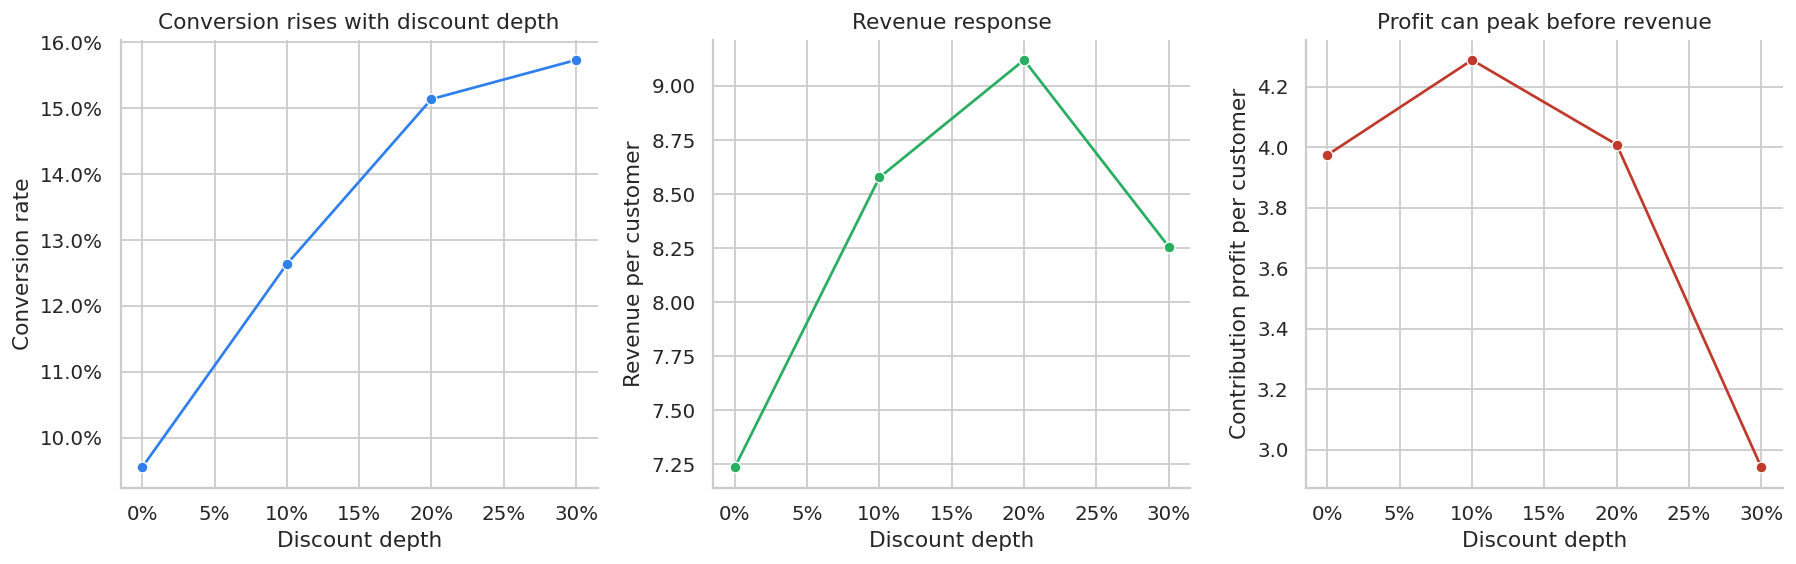

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

sns.lineplot(data=discount_readout, x="discount_depth", y="conversion_rate", marker="o", ax=axes[0], color="#2F80ED")
axes[0].set_title("Conversion rises with discount depth")
axes[0].set_xlabel("Discount depth")
axes[0].set_ylabel("Conversion rate")
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{100*x:.1f}%")

sns.lineplot(data=discount_readout, x="discount_depth", y="revenue_per_customer", marker="o", ax=axes[1], color="#27AE60")
axes[1].set_title("Revenue response")
axes[1].set_xlabel("Discount depth")
axes[1].set_ylabel("Revenue per customer")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")

sns.lineplot(data=discount_readout, x="discount_depth", y="profit_per_customer", marker="o", ax=axes[2], color="#C0392B")
axes[2].set_title("Profit can peak before revenue")
axes[2].set_xlabel("Discount depth")
axes[2].set_ylabel("Contribution profit per customer")
axes[2].xaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")

plt.tight_layout()
plt.show()

The promotion decision should be made on contribution profit and strategic constraints, not conversion alone. A 30% discount may generate more purchases, but those purchases can be less profitable.

This is a common industry mistake: optimizing promotions on conversion rate or gross revenue while ignoring margin.

## 9. Heterogeneous Discount Response

Promotions often work best for specific customer segments. In this simulation, customers differ in price sensitivity and loyalty.

We can use the randomized experiment to estimate segment-level treatment effects. This is not yet a causal ML model; it is a simple subgroup readout.

In [14]:
segmented = discounts.copy()
segmented["price_sensitivity_segment"] = pd.qcut(
    segmented["price_sensitivity"],
    q=3,
    labels=["Low price sensitivity", "Medium price sensitivity", "High price sensitivity"],
)
segmented["loyalty_segment"] = pd.qcut(
    segmented["loyalty"],
    q=3,
    labels=["Low loyalty", "Medium loyalty", "High loyalty"],
)

segment_profit = (
    segmented.groupby(["price_sensitivity_segment", "discount_depth"], observed=True)
    .agg(profit_per_customer=("contribution_profit", "mean"), conversion_rate=("purchased", "mean"))
    .reset_index()
)

control_segment = segment_profit.query("discount_depth == 0")[
    ["price_sensitivity_segment", "profit_per_customer"]
].rename(columns={"profit_per_customer": "control_profit"})

segment_profit = segment_profit.merge(control_segment, on="price_sensitivity_segment")
segment_profit["incremental_profit"] = segment_profit["profit_per_customer"] - segment_profit["control_profit"]

display(
    styled_table(
        segment_profit,
        money_cols=["profit_per_customer", "control_profit", "incremental_profit"],
        pct_cols=["discount_depth", "conversion_rate"],
    )
)

,price_sensitivity_segment,discount_depth,profit_per_customer,conversion_rate,control_profit,incremental_profit
0,Low price sensitivity,0.0%,$3.98,9.6%,$3.98,$0.00
1,Low price sensitivity,10.0%,$3.95,11.7%,$3.98,$-0.03
2,Low price sensitivity,20.0%,$3.37,12.8%,$3.98,$-0.62
3,Low price sensitivity,30.0%,$2.09,11.2%,$3.98,$-1.90
4,Medium price sensitivity,0.0%,$4.14,9.9%,$4.14,$0.00
5,Medium price sensitivity,10.0%,$4.27,12.5%,$4.14,$0.13
6,Medium price sensitivity,20.0%,$3.91,14.7%,$4.14,$-0.23
7,Medium price sensitivity,30.0%,$2.85,15.3%,$4.14,$-1.30
8,High price sensitivity,0.0%,$3.80,9.1%,$3.80,$0.00
9,High price sensitivity,10.0%,$4.64,13.7%,$3.80,$0.84


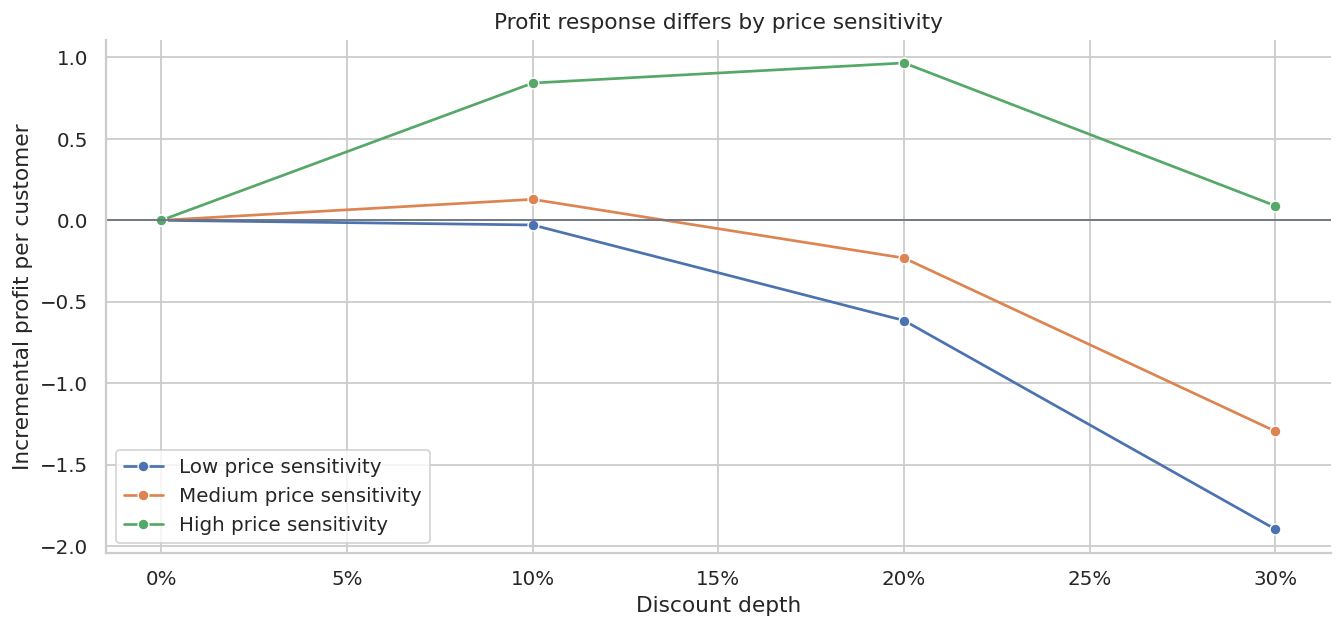

In [15]:
fig, ax = plt.subplots(figsize=(10.5, 5))
sns.lineplot(
    data=segment_profit,
    x="discount_depth",
    y="incremental_profit",
    hue="price_sensitivity_segment",
    marker="o",
    ax=ax,
)
ax.axhline(0, color="#6B7280", linewidth=1)
ax.set_title("Profit response differs by price sensitivity")
ax.set_xlabel("Discount depth")
ax.set_ylabel("Incremental profit per customer")
ax.xaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")
ax.legend(title="")
plt.tight_layout()
plt.show()

This is the bridge from pricing experiments to personalization:

- broad discounts may be wasteful for customers who would buy anyway,
- targeted discounts may be profitable for price-sensitive customers,
- aggressive discounts can train customers to wait for promotions.

The next layer would be a CATE or policy-learning model trained on randomized discount data.

## 10. Promotion Timing and Stockpiling

For storable products, promotion-week sales can overstate incremental demand. Customers may buy earlier than they otherwise would have, then buy less after the promotion.

Hendel and Nevo (2006) explicitly study sales and consumer inventory, emphasizing that temporary price reductions can create both current sales spikes and demand accumulation or stockpiling behavior. In industry, this means we should inspect cumulative effects, not only same-week lift.

In [16]:
def simulate_stockpiling_panel(n_stores=30, n_weeks=60, seed=333):
    local_rng = np.random.default_rng(seed)
    rows = []
    stores = [f"Store_{i:02d}" for i in range(n_stores)]
    store_scale = pd.Series(local_rng.lognormal(mean=7.2, sigma=0.25, size=n_stores), index=stores)

    promo_weeks = {12, 13, 28, 42}
    for store in stores:
        local_scale = store_scale[store]
        for week in range(n_weeks):
            promotion = int(week in promo_weeks)
            lag1 = int((week - 1) in promo_weeks)
            lag2 = int((week - 2) in promo_weeks)
            season = 0.12 * np.sin(2 * np.pi * week / 26) + 0.05 * np.cos(2 * np.pi * week / 13)
            noise = local_rng.normal(0, 0.08)

            # Promotions create a current spike and then post-promotion demand dips.
            log_units = (
                np.log(local_scale)
                + season
                + 0.48 * promotion
                - 0.18 * lag1
                - 0.10 * lag2
                + noise
            )
            units = np.exp(log_units)
            base_price = 12.0
            price = base_price * (0.78 if promotion else 1.0)
            unit_cost = 5.2

            rows.append(
                {
                    "store": store,
                    "week": week,
                    "promotion": promotion,
                    "promo_lag1": lag1,
                    "promo_lag2": lag2,
                    "price": price,
                    "units": units,
                    "revenue": price * units,
                    "contribution_profit": (price - unit_cost) * units,
                }
            )

    df = pd.DataFrame(rows)
    df["log_units"] = np.log(df["units"])
    return df


stockpile = simulate_stockpiling_panel()

weekly_stockpile = (
    stockpile.groupby("week")
    .agg(units=("units", "mean"), promotion=("promotion", "max"))
    .reset_index()
)

display(stockpile.head())

,store,week,promotion,promo_lag1,promo_lag2,price,units,revenue,contribution_profit,log_units
0,Store_00,0,0,0,0,12.0,1119.652637,13435.831641,7613.637930,7.020774
1,Store_00,1,0,0,0,12.0,1338.838339,16066.060073,9104.100708,7.199558
2,Store_00,2,0,0,0,12.0,1054.374796,12652.497549,7169.748611,6.960703
3,Store_00,3,0,0,0,12.0,1055.424772,12665.097268,7176.888452,6.961699
4,Store_00,4,0,0,0,12.0,1238.167522,14858.010263,8419.539149,7.121388


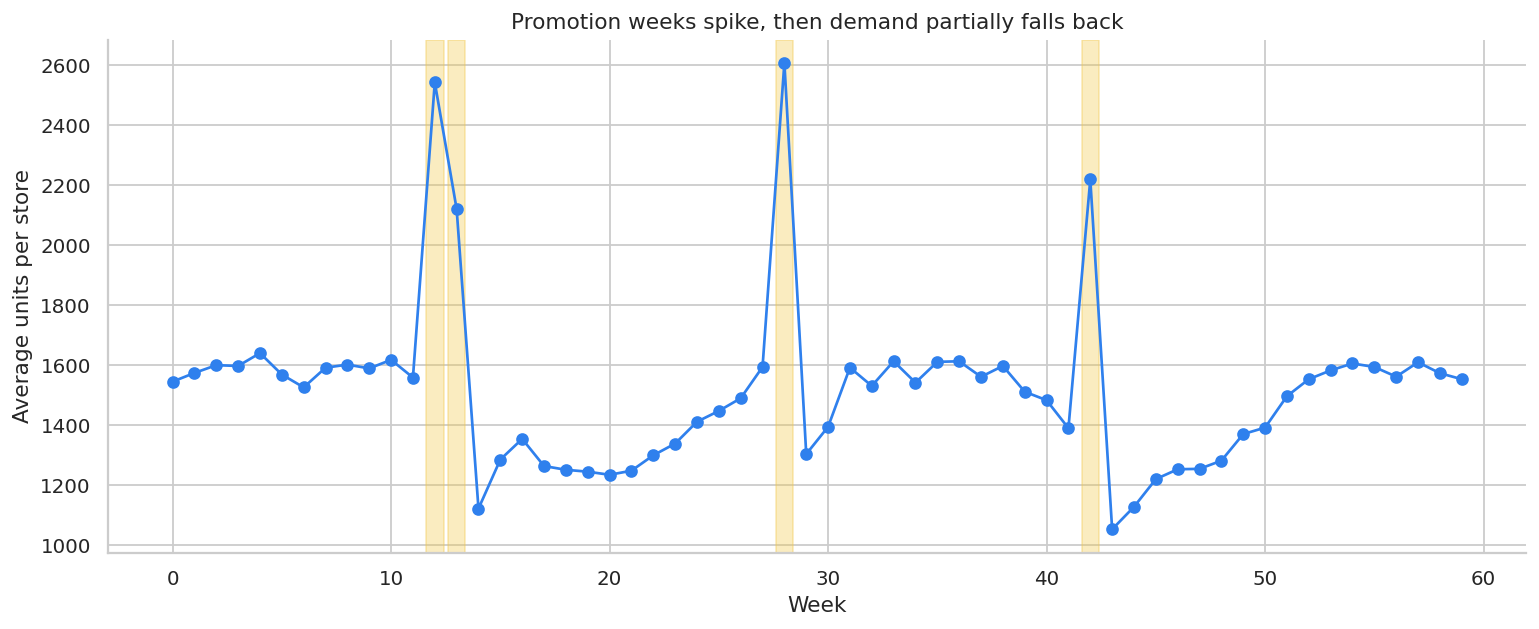

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekly_stockpile["week"], weekly_stockpile["units"], marker="o", color="#2F80ED")
for promo_week in weekly_stockpile.loc[weekly_stockpile["promotion"].eq(1), "week"]:
    ax.axvspan(promo_week - 0.4, promo_week + 0.4, color="#F2C94C", alpha=0.35)
ax.set_title("Promotion weeks spike, then demand partially falls back")
ax.set_xlabel("Week")
ax.set_ylabel("Average units per store")
plt.tight_layout()
plt.show()

In [18]:
same_week_model = smf.ols(
    "log_units ~ promotion + C(store) + C(week)",
    data=stockpile,
).fit(cov_type="cluster", cov_kwds={"groups": stockpile["store"]})

distributed_lag_model = smf.ols(
    "log_units ~ promotion + promo_lag1 + promo_lag2 + C(store) + C(week)",
    data=stockpile,
).fit(cov_type="cluster", cov_kwds={"groups": stockpile["store"]})

lag_readout = pd.DataFrame(
    [
        {
            "effect": "Same-week promotion effect",
            "estimate_log_points": distributed_lag_model.params["promotion"],
            "approx_percent_effect": np.exp(distributed_lag_model.params["promotion"]) - 1,
        },
        {
            "effect": "Week +1 pull-forward effect",
            "estimate_log_points": distributed_lag_model.params["promo_lag1"],
            "approx_percent_effect": np.exp(distributed_lag_model.params["promo_lag1"]) - 1,
        },
        {
            "effect": "Week +2 pull-forward effect",
            "estimate_log_points": distributed_lag_model.params["promo_lag2"],
            "approx_percent_effect": np.exp(distributed_lag_model.params["promo_lag2"]) - 1,
        },
    ]
)

same_week_only = same_week_model.params["promotion"]
distributed_total = (
    distributed_lag_model.params["promotion"]
    + distributed_lag_model.params["promo_lag1"]
    + distributed_lag_model.params["promo_lag2"]
)

display(styled_table(lag_readout, pct_cols=["approx_percent_effect"], ratio_cols=["estimate_log_points"]))
print(f"Same-week-only log effect: {same_week_only:.3f}")
print(f"Distributed 3-week cumulative log effect: {distributed_total:.3f}")

,effect,estimate_log_points,approx_percent_effect
0,Same-week promotion effect,0.376,45.6%
1,Week +1 pull-forward effect,-0.149,-13.9%
2,Week +2 pull-forward effect,-0.148,-13.8%


Same-week-only log effect: 0.346
Distributed 3-week cumulative log effect: 0.078


The same-week promotion coefficient captures the spike. The distributed-lag model also estimates the post-promotion dips. For storable products, the cumulative effect can be much smaller than the week-of-promotion effect.

This distinction matters for:

- grocery and consumer packaged goods,
- subscription annual plans,
- travel and ticketing,
- durable goods,
- any category where customers can shift purchase timing.

## 11. Common Pricing and Promotion Threats

A pricing analysis should include a threat model. The table below is a practical checklist.

In [19]:
pricing_threats = pd.DataFrame(
    [
        {
            "threat": "Price endogeneity",
            "symptom": "Observed price increases during high-demand periods.",
            "diagnostic": "Plot prices against demand forecasts, events, and inventory.",
            "mitigation": "Randomize prices, use valid instruments, or exploit policy rules.",
        },
        {
            "threat": "Stockouts",
            "symptom": "Low price appears to reduce sales because inventory runs out.",
            "diagnostic": "Track availability, stockout flags, and lost sales.",
            "mitigation": "Model censored demand or exclude stockout windows.",
        },
        {
            "threat": "Competitor reaction",
            "symptom": "Competitors match prices after treatment starts.",
            "diagnostic": "Monitor competitor prices and market share.",
            "mitigation": "Short tests, geo tests, or models with competitor controls.",
        },
        {
            "threat": "Customer interference",
            "symptom": "Customers share coupons or compare prices across accounts.",
            "diagnostic": "Measure redemption leakage and cross-account behavior.",
            "mitigation": "Randomize at household, geo, or market level.",
        },
        {
            "threat": "Reference price effects",
            "symptom": "Future full-price conversion declines after repeated discounts.",
            "diagnostic": "Track long-run conversion and willingness to pay.",
            "mitigation": "Limit discount frequency and measure delayed outcomes.",
        },
        {
            "threat": "Margin mix shift",
            "symptom": "Sales lift comes from low-margin products or expensive fulfillment.",
            "diagnostic": "Use contribution margin by order, not only revenue.",
            "mitigation": "Optimize on profit and guardrail product mix.",
        },
        {
            "threat": "Fairness or regulatory risk",
            "symptom": "Personalized prices create unacceptable disparities.",
            "diagnostic": "Audit price exposure by protected and sensitive segments.",
            "mitigation": "Use policy constraints and legal review.",
        },
    ]
)

display(pricing_threats)

,threat,symptom,diagnostic,mitigation
0,Price endogeneity,Observed price increases during high-demand pe...,"Plot prices against demand forecasts, events, ...","Randomize prices, use valid instruments, or ex..."
1,Stockouts,Low price appears to reduce sales because inve...,"Track availability, stockout flags, and lost s...",Model censored demand or exclude stockout wind...
2,Competitor reaction,Competitors match prices after treatment starts.,Monitor competitor prices and market share.,"Short tests, geo tests, or models with competi..."
3,Customer interference,Customers share coupons or compare prices acro...,Measure redemption leakage and cross-account b...,"Randomize at household, geo, or market level."
4,Reference price effects,Future full-price conversion declines after re...,Track long-run conversion and willingness to pay.,Limit discount frequency and measure delayed o...
5,Margin mix shift,Sales lift comes from low-margin products or e...,"Use contribution margin by order, not only rev...",Optimize on profit and guardrail product mix.
6,Fairness or regulatory risk,Personalized prices create unacceptable dispar...,Audit price exposure by protected and sensitiv...,Use policy constraints and legal review.


## 12. Power Planning for Discount Tests

For randomized discount experiments, we can do a simple minimum detectable effect calculation on profit per customer.

For two equal-sized groups:

$$
\text{MDE} = (z_{1-\alpha/2}+z_{\text{power}})\sqrt{\frac{2\sigma^2}{n}}
$$

For unequal groups, use:

$$
\text{MDE} = (z_{1-\alpha/2}+z_{\text{power}})\sqrt{\frac{\sigma^2}{n_t}+\frac{\sigma^2}{n_c}}
$$

In [20]:
def mde_two_group(sd, n_treat, n_control, alpha=0.05, power=0.80):
    return (norm.ppf(1 - alpha / 2) + norm.ppf(power)) * sd * np.sqrt(1 / n_treat + 1 / n_control)


profit_sd = discounts["contribution_profit"].std(ddof=1)
power_rows = []
for total_n in [10_000, 25_000, 50_000, 100_000, 250_000]:
    n_per_arm = total_n // 4
    mde = mde_two_group(profit_sd, n_per_arm, n_per_arm)
    power_rows.append(
        {
            "total_customers": total_n,
            "customers_per_arm": n_per_arm,
            "mde_profit_per_customer": mde,
            "mde_total_profit_if_scaled_to_all": mde * total_n,
        }
    )

power_discount = pd.DataFrame(power_rows)

display(
    styled_table(
        power_discount,
        money_cols=["mde_profit_per_customer", "mde_total_profit_if_scaled_to_all"],
    )
)

,total_customers,customers_per_arm,mde_profit_per_customer,mde_total_profit_if_scaled_to_all
0,10000,2500,$0.83,"$8,302"
1,25000,6250,$0.53,"$13,126"
2,50000,12500,$0.37,"$18,564"
3,100000,25000,$0.26,"$26,253"
4,250000,62500,$0.17,"$41,510"


If the MDE is larger than the profit difference that would change the decision, the experiment is underpowered for the business question. In that case, the team should either increase sample size, reduce the number of arms, extend the measurement window, or accept that the test is exploratory.

## 13. Decision Memo Template

A pricing readout should make the decision explicit. Below is a concise example using the simulated discount experiment.

In [21]:
best_discount = discount_readout.loc[discount_readout["profit_per_customer"].idxmax()]
control_profit = discount_readout.loc[discount_readout["discount_depth"].eq(0), "profit_per_customer"].iloc[0]
best_lift = best_discount["profit_per_customer"] - control_profit

recommended_depth = best_discount["discount_depth"]
eligible_customers = 600_000
expected_incremental_profit = best_lift * eligible_customers

memo = f'''
### Pricing and Promotion Readout

**Decision:** Select discount depth for the next eligible-customer promotion.

**Design:** Randomized discount-depth experiment with four arms: 0%, 10%, 20%, and 30%.

**Primary outcome:** Contribution profit per eligible customer.

**Best observed arm:** {pct(recommended_depth, 0)} discount.

**Profit per customer in best arm:** {dollars(best_discount["profit_per_customer"], 2)}.

**Incremental profit per customer versus no discount:** {dollars(best_lift, 2)}.

**Expected incremental profit if scaled to {eligible_customers:,} eligible customers:** {dollars(expected_incremental_profit, 0)}.

**Recommendation:** Use the profit-maximizing discount depth for price-sensitive segments, but avoid broad deep discounting until delayed outcomes are measured.

**Caveats:** Monitor future full-price conversion, coupon leakage, product mix, customer fairness, and support or fulfillment costs.
'''

display(Markdown(memo))


### Pricing and Promotion Readout

**Decision:** Select discount depth for the next eligible-customer promotion.

**Design:** Randomized discount-depth experiment with four arms: 0%, 10%, 20%, and 30%.

**Primary outcome:** Contribution profit per eligible customer.

**Best observed arm:** 10% discount.

**Profit per customer in best arm:** $4.29.

**Incremental profit per customer versus no discount:** $0.31.

**Expected incremental profit if scaled to 600,000 eligible customers:** $188,271.

**Recommendation:** Use the profit-maximizing discount depth for price-sensitive segments, but avoid broad deep discounting until delayed outcomes are measured.

**Caveats:** Monitor future full-price conversion, coupon leakage, product mix, customer fairness, and support or fulfillment costs.


The recommendation is deliberately not "send the deepest discount to everyone." A mature pricing decision combines the immediate causal estimate with strategic guardrails.

## 14. Practical Workflow

A professional pricing or promotion analysis usually follows this sequence:

1. Define the decision: raise price, lower price, discount, target, or pause.
2. Define the estimand: elasticity, profit lift, conversion lift, retention, or long-run value.
3. Identify the source of price variation: randomization, cost shock, policy rule, rollout, or observational panel.
4. Audit endogeneity: why did prices vary historically?
5. Choose the unit of analysis: customer, SKU, store, market, or week.
6. Include margin, inventory, and stockout measures.
7. Estimate short-run and delayed effects.
8. Report uncertainty and decision-relevant MDE.
9. Translate estimates into price, discount, or targeting recommendations.
10. Monitor post-launch guardrails.

## Hands-On Extensions

Try extending this notebook in the following ways:

- Add competitor prices to the pricing panel.
- Simulate stockouts and show how observed sales understate demand.
- Replace the constant-elasticity profit curve with a nonparametric demand curve.
- Add heterogeneous elasticity by product category.
- Estimate a causal forest for discount response using the randomized discount data.
- Compare customer-level and geo-level randomization for personalized pricing constraints.
- Build a dashboard that shows revenue, margin, and long-run guardrails side by side.

## Key Takeaways

- Price elasticity is causal: it asks how demand would change under a counterfactual price.
- Observed prices are often endogenous because firms set prices in response to demand conditions.
- Fixed effects help, but they do not solve endogeneity when unobserved demand shocks drive price.
- Valid instruments or randomized price variation can identify causal demand response.
- Promotion evaluation should use contribution profit, not only conversion or revenue.
- Discount depth can have heterogeneous effects across customer segments.
- Promotions can pull demand forward, so cumulative effects matter.
- A professional pricing readout connects estimates to price decisions, margin, uncertainty, and operational risks.

## References

Anderson, E. T., & Simester, D. (2003). Effects of $9 price endings on retail sales: Evidence from field experiments. *Quantitative Marketing and Economics, 1*(1), 93-110. https://doi.org/10.1023/A:1023581927405

Hendel, I., & Nevo, A. (2006). Sales and consumer inventory. *The RAND Journal of Economics, 37*(3), 543-561. https://doi.org/10.1111/j.1756-2171.2006.tb00030.x

Mela, C. F., Gupta, S., & Lehmann, D. R. (1997). The long-term impact of promotion and advertising on consumer brand choice. *Journal of Marketing Research, 34*(2), 248-261. https://doi.org/10.1177/002224379703400205

Pauwels, K., Hanssens, D. M., & Siddarth, S. (2002). The long-term effects of price promotions on category incidence, brand choice, and purchase quantity. *Journal of Marketing Research, 39*(4), 421-439. https://doi.org/10.1509/jmkr.39.4.421.19114

Qiang, S., & Bayati, M. (2016). Dynamic pricing with demand covariates. *SSRN Electronic Journal*. https://doi.org/10.2139/ssrn.2765257